In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

In [2]:
ds_prec = xr.open_dataset(r"C:\Users\USER\Desktop\MA\111-2\CAD\Week5\precip.mon.mean.nc")
#select period
ds_prec = ds_prec.sel(time=slice('1991', '2019'))
#ds
#actually load the data
ds_prec.load()

<xarray.Dataset>
Dimensions:    (lat: 72, lon: 144, time: 348, nv: 2)
Coordinates:
  * lat        (lat) float32 -88.75 -86.25 -83.75 -81.25 ... 83.75 86.25 88.75
  * lon        (lon) float32 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
  * time       (time) datetime64[ns] 1991-01-01 1991-02-01 ... 2019-12-01
Dimensions without coordinates: nv
Data variables:
    time_bnds  (time, nv) datetime64[ns] 1991-01-01 1991-02-01 ... 2020-01-01
    lat_bnds   (lat, nv) float32 -90.0 -87.5 -87.5 -85.0 ... 85.0 87.5 87.5 90.0
    lon_bnds   (lon, nv) float32 0.0 2.5 2.5 5.0 5.0 ... 355.0 357.5 357.5 360.0
    precip     (time, lat, lon) float32 0.04712 0.0 0.0 ... 0.1305 0.1327 0.1341
Attributes: (12/18)
    Conventions:           CF-1.0
    curator:               Dr. Jian-Jian Wang\nESSIC, University of Maryland ...
    citation:              Adler, R.F., G.J. Huffman, A. Chang, R. Ferraro, P...
    title:                 GPCP Version 2.3 Combined Precipitation Dataset (F...
    platform:              NOAA POES (Polar Orbiting Environmental Satellites)
    source_obs:            CDR RSS SSMI/SSMIS Tbs over ocean \nCDR SSMI/SSMIS...
    ...                    ...
    source:                https://www.ncei.noaa.gov/data/global-precipitatio...
    source_documentation:  https://www.ncdc.noaa.gov/cdr/atmospheric/precipit...
    NCO:                   4.6.9
    history:               Generated at NOAA/ESRL PSD Sep 9 2016 based on dat...
    References:            http://www.psl.noaa.gov/data/gridded/data.gpcp.html
    data_comment:          Interim data covers 2023/01 through latest.

c:\Users\USER\anaconda3\envs\UMCC_111_1\lib\site-packages\xarray\core\indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  indexer = self.index.get_loc(
c:\Users\USER\anaconda3\envs\UMCC_111_1\lib\site-packages\xarray\core\indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  indexer = self.index.get_loc(


Text(0.5, 1.0, 'Taiwan precipitation (mm)')

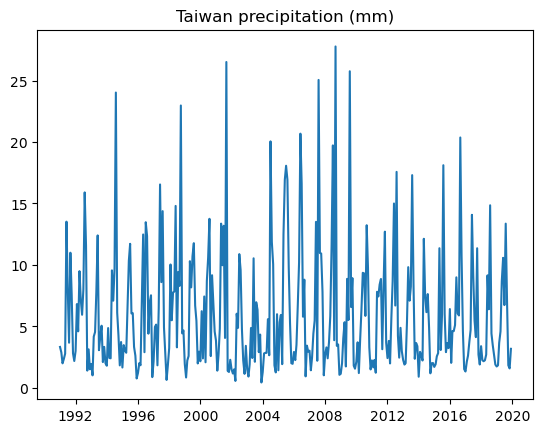

In [3]:
ds_pt_taiwan = ds_prec.sel(lat = 23.5,lon = 120,method = 'nearest')
plt.plot(ds_pt_taiwan['time'],ds_pt_taiwan['precip'])
plt.title('Taiwan precipitation (mm)')

c:\Users\USER\anaconda3\envs\UMCC_111_1\lib\site-packages\xarray\core\indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  indexer = self.index.get_loc(
c:\Users\USER\anaconda3\envs\UMCC_111_1\lib\site-packages\xarray\core\indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  indexer = self.index.get_loc(


Text(0.5, 1.0, 'Hawaii precipitation (mm)')

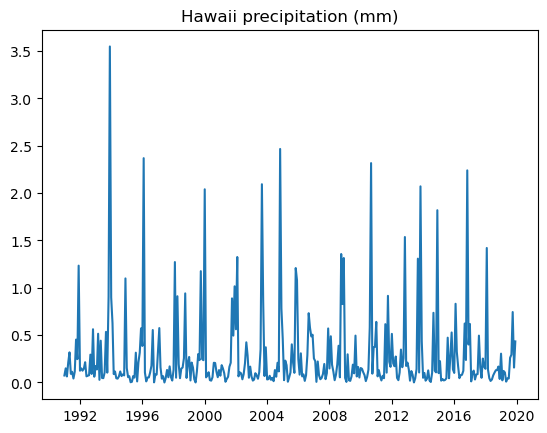

In [4]:
ds_pt_hawaii = ds_prec.sel(lat = 20,lon = 335,method = 'nearest')     #20, 205
plt.plot(ds_pt_hawaii['time'],ds_pt_hawaii['precip'])
plt.title('Hawaii precipitation (mm)')

In [5]:
ds_climo = ds_prec.groupby('time.month').mean(dim = 'time')
ds_climo

<xarray.Dataset>
Dimensions:   (lat: 72, lon: 144, month: 12, nv: 2)
Coordinates:
  * lat       (lat) float32 -88.75 -86.25 -83.75 -81.25 ... 83.75 86.25 88.75
  * lon       (lon) float32 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
  * month     (month) int64 1 2 3 4 5 6 7 8 9 10 11 12
Dimensions without coordinates: nv
Data variables:
    lat_bnds  (month, lat, nv) float32 -90.0 -87.5 -87.5 ... 87.5 87.5 90.0
    lon_bnds  (month, lon, nv) float32 0.0 2.5 2.5 5.0 ... 357.5 357.5 360.0
    precip    (month, lat, lon) float32 0.02272 0.03013 0.03598 ... 0.4214 0.373

c:\Users\USER\anaconda3\envs\UMCC_111_1\lib\site-packages\xarray\core\indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  indexer = self.index.get_loc(
c:\Users\USER\anaconda3\envs\UMCC_111_1\lib\site-packages\xarray\core\indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  indexer = self.index.get_loc(


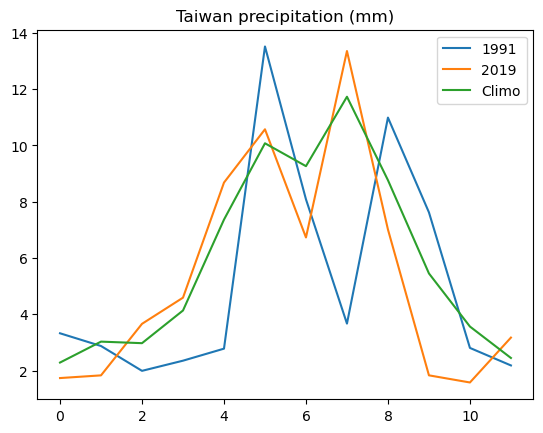

In [6]:
ds_ptclimo = ds_climo.sel(lat = 23.5,lon = 120,method = 'nearest')
ds_pt1991_taiwan = ds_pt_taiwan.sel(time = slice('1991-01-01','1991-12-01'))
ds_pt2019_taiwan = ds_pt_taiwan.sel(time = slice('2019-01-01','2019-12-01'))
                    
plt.plot(ds_pt1991_taiwan['precip'])
plt.plot(ds_pt2019_taiwan['precip'])                    
plt.plot(ds_ptclimo['precip'])
plt.title('Taiwan precipitation (mm)')
plt.legend(['1991','2019','Climo'])

In [7]:
ds_anoms = ds_prec.groupby('time.month')-ds_climo
ds_anoms

<xarray.Dataset>
Dimensions:   (lat: 72, lon: 144, time: 348, nv: 2)
Coordinates:
  * lat       (lat) float32 -88.75 -86.25 -83.75 -81.25 ... 83.75 86.25 88.75
  * lon       (lon) float32 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
  * time      (time) datetime64[ns] 1991-01-01 1991-02-01 ... 2019-12-01
    month     (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12
Dimensions without coordinates: nv
Data variables:
    lat_bnds  (time, lat, nv) float32 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    lon_bnds  (time, lon, nv) float32 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    precip    (time, lat, lon) float32 0.0244 -0.03013 ... -0.2888 -0.2389

c:\Users\USER\anaconda3\envs\UMCC_111_1\lib\site-packages\xarray\core\indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  indexer = self.index.get_loc(
c:\Users\USER\anaconda3\envs\UMCC_111_1\lib\site-packages\xarray\core\indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  indexer = self.index.get_loc(


Text(0.5, 1.0, 'Taiwan precipitation Anomalies (mm)')

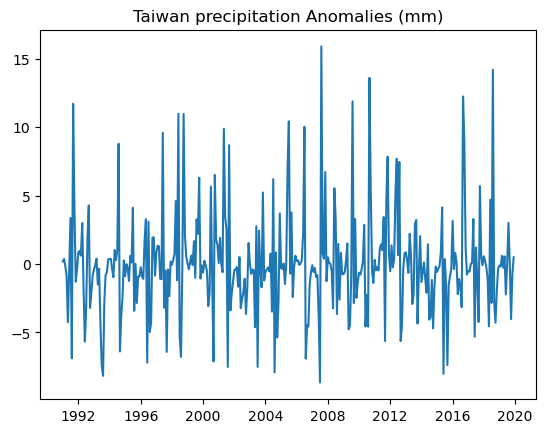

In [8]:
ds_anomspt = ds_anoms.sel(lat = 21.5,lon = 120,method = 'nearest')
plt.plot(ds_anomspt['time'],ds_anomspt['precip'])
plt.title('Taiwan precipitation Anomalies (mm)')

c:\Users\USER\anaconda3\envs\UMCC_111_1\lib\site-packages\xarray\core\indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  indexer = self.index.get_loc(
c:\Users\USER\anaconda3\envs\UMCC_111_1\lib\site-packages\xarray\core\indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  indexer = self.index.get_loc(


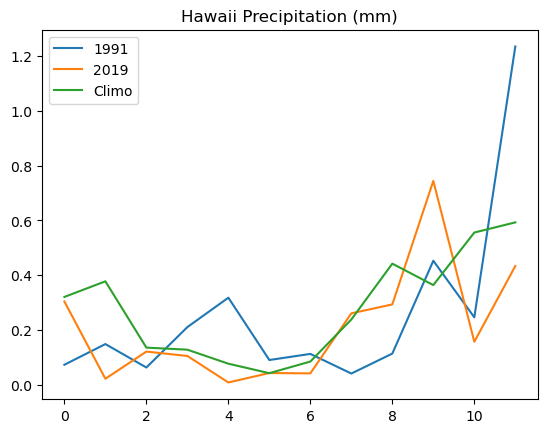

In [9]:
ds_ptclimo = ds_climo.sel(lat = 20,lon = 335,method = 'nearest')
ds_pt1991_hawaii = ds_pt_hawaii.sel(time = slice('1991-01-01','1991-12-01'))
ds_pt2019_hawaii = ds_pt_hawaii.sel(time = slice('2019-01-01','2019-12-01'))
                    
plt.plot(ds_pt1991_hawaii['precip'])
plt.plot(ds_pt2019_hawaii['precip'])                    
plt.plot(ds_ptclimo['precip'])
plt.title('Hawaii Precipitation (mm)')
plt.legend(['1991','2019','Climo'])

c:\Users\USER\anaconda3\envs\UMCC_111_1\lib\site-packages\xarray\core\indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  indexer = self.index.get_loc(
c:\Users\USER\anaconda3\envs\UMCC_111_1\lib\site-packages\xarray\core\indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  indexer = self.index.get_loc(


Text(0.5, 1.0, 'Hawaii Precipitation Anomalies (mm)')

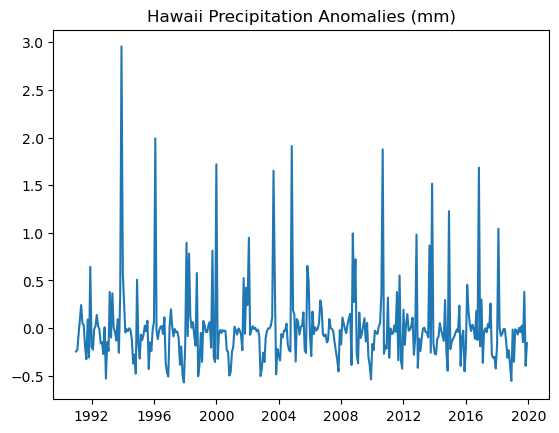

In [10]:
ds_anomspt = ds_anoms.sel(lat = 20,lon = 335,method = 'nearest')
plt.plot(ds_anomspt['time'],ds_anomspt['precip'])
plt.title('Hawaii Precipitation Anomalies (mm)')